<a href="https://colab.research.google.com/github/NataliaFaro/FASE_04_CTWP_Cap3/blob/main/Cap3_Seeds_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASE 04 - CTWP - Capítulo 3

## Business Understanding

A classificação manual de grãos de trigo em cooperativas agrícolas pode ser lenta e sujeita a erros humanos.

Este projeto tem como objetivo aplicar técnicas de Machine Learning para automatizar a classificação de variedades de trigo utilizando o Seeds Dataset do UCI Machine Learning Repository.

As variedades analisadas são:

- Kama
- Rosa
- Canadian

A metodologia utilizada será a CRISP-DM, contemplando:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment (documentação dos resultados)

O objetivo é identificar qual algoritmo apresenta melhor desempenho para a classificação dos grãos.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
# Nomes das colunas

colunas = [
    'Area',
    'Perimeter',
    'Compactness',
    'Kernel_Length',
    'Kernel_Width',
    'Asymmetry_Coefficient',
    'Kernel_Groove_Length',
    'Class'
]

# Leitura do dataset

df = pd.read_csv(
    'seeds_dataset.txt',
    sep=r'\s+',
    header=None,
    names=colunas
)

# Exibir as 5 primeiras linhas

df.head()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Kernel_Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
# Quantidade de linhas e colunas

print("Dimensões do dataset:")
print(df.shape)

print("\nInformações gerais:")
df.info()

Dimensões do dataset:
(210, 8)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area                   210 non-null    float64
 1   Perimeter              210 non-null    float64
 2   Compactness            210 non-null    float64
 3   Kernel_Length          210 non-null    float64
 4   Kernel_Width           210 non-null    float64
 5   Asymmetry_Coefficient  210 non-null    float64
 6   Kernel_Groove_Length   210 non-null    float64
 7   Class                  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [ ]:
# Estatísticas descritivas

df.describe()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Kernel_Groove_Length,Class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [ ]:
# Mediana das variáveis

df.median(numeric_only=True)

,0
Area,14.35500
Perimeter,14.32000
Compactness,0.87345
Kernel_Length,5.52350
Kernel_Width,3.23700
Asymmetry_Coefficient,3.59900
Kernel_Groove_Length,5.22300
Class,2.00000


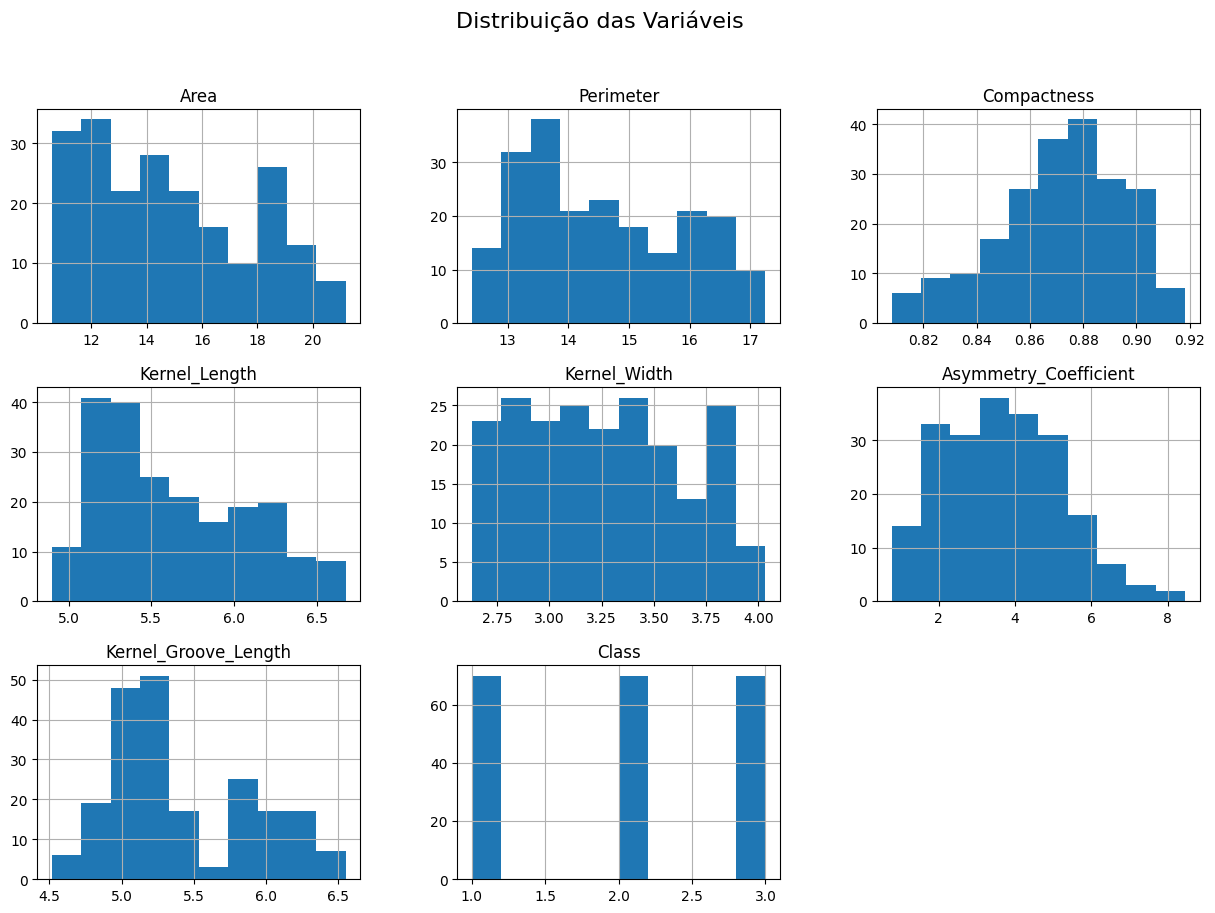

In [ ]:
# Histogramas

df.hist(figsize=(15,10))

plt.suptitle('Distribuição das Variáveis', fontsize=16)

plt.show()

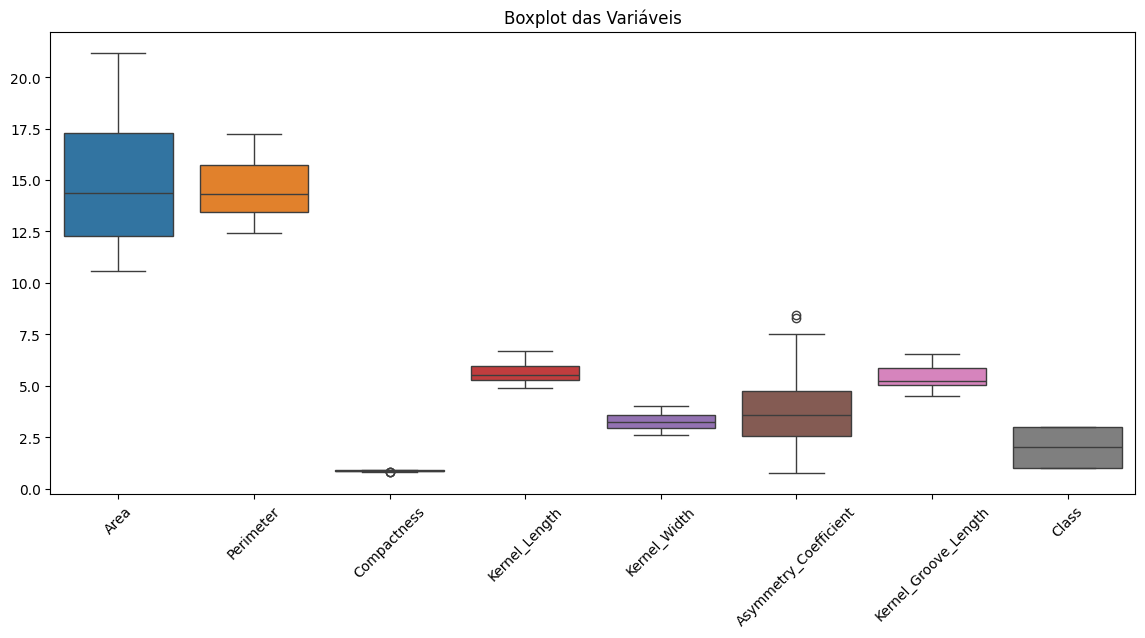

In [ ]:
# Boxplots

plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.title('Boxplot das Variáveis')

plt.xticks(rotation=45)

plt.show()

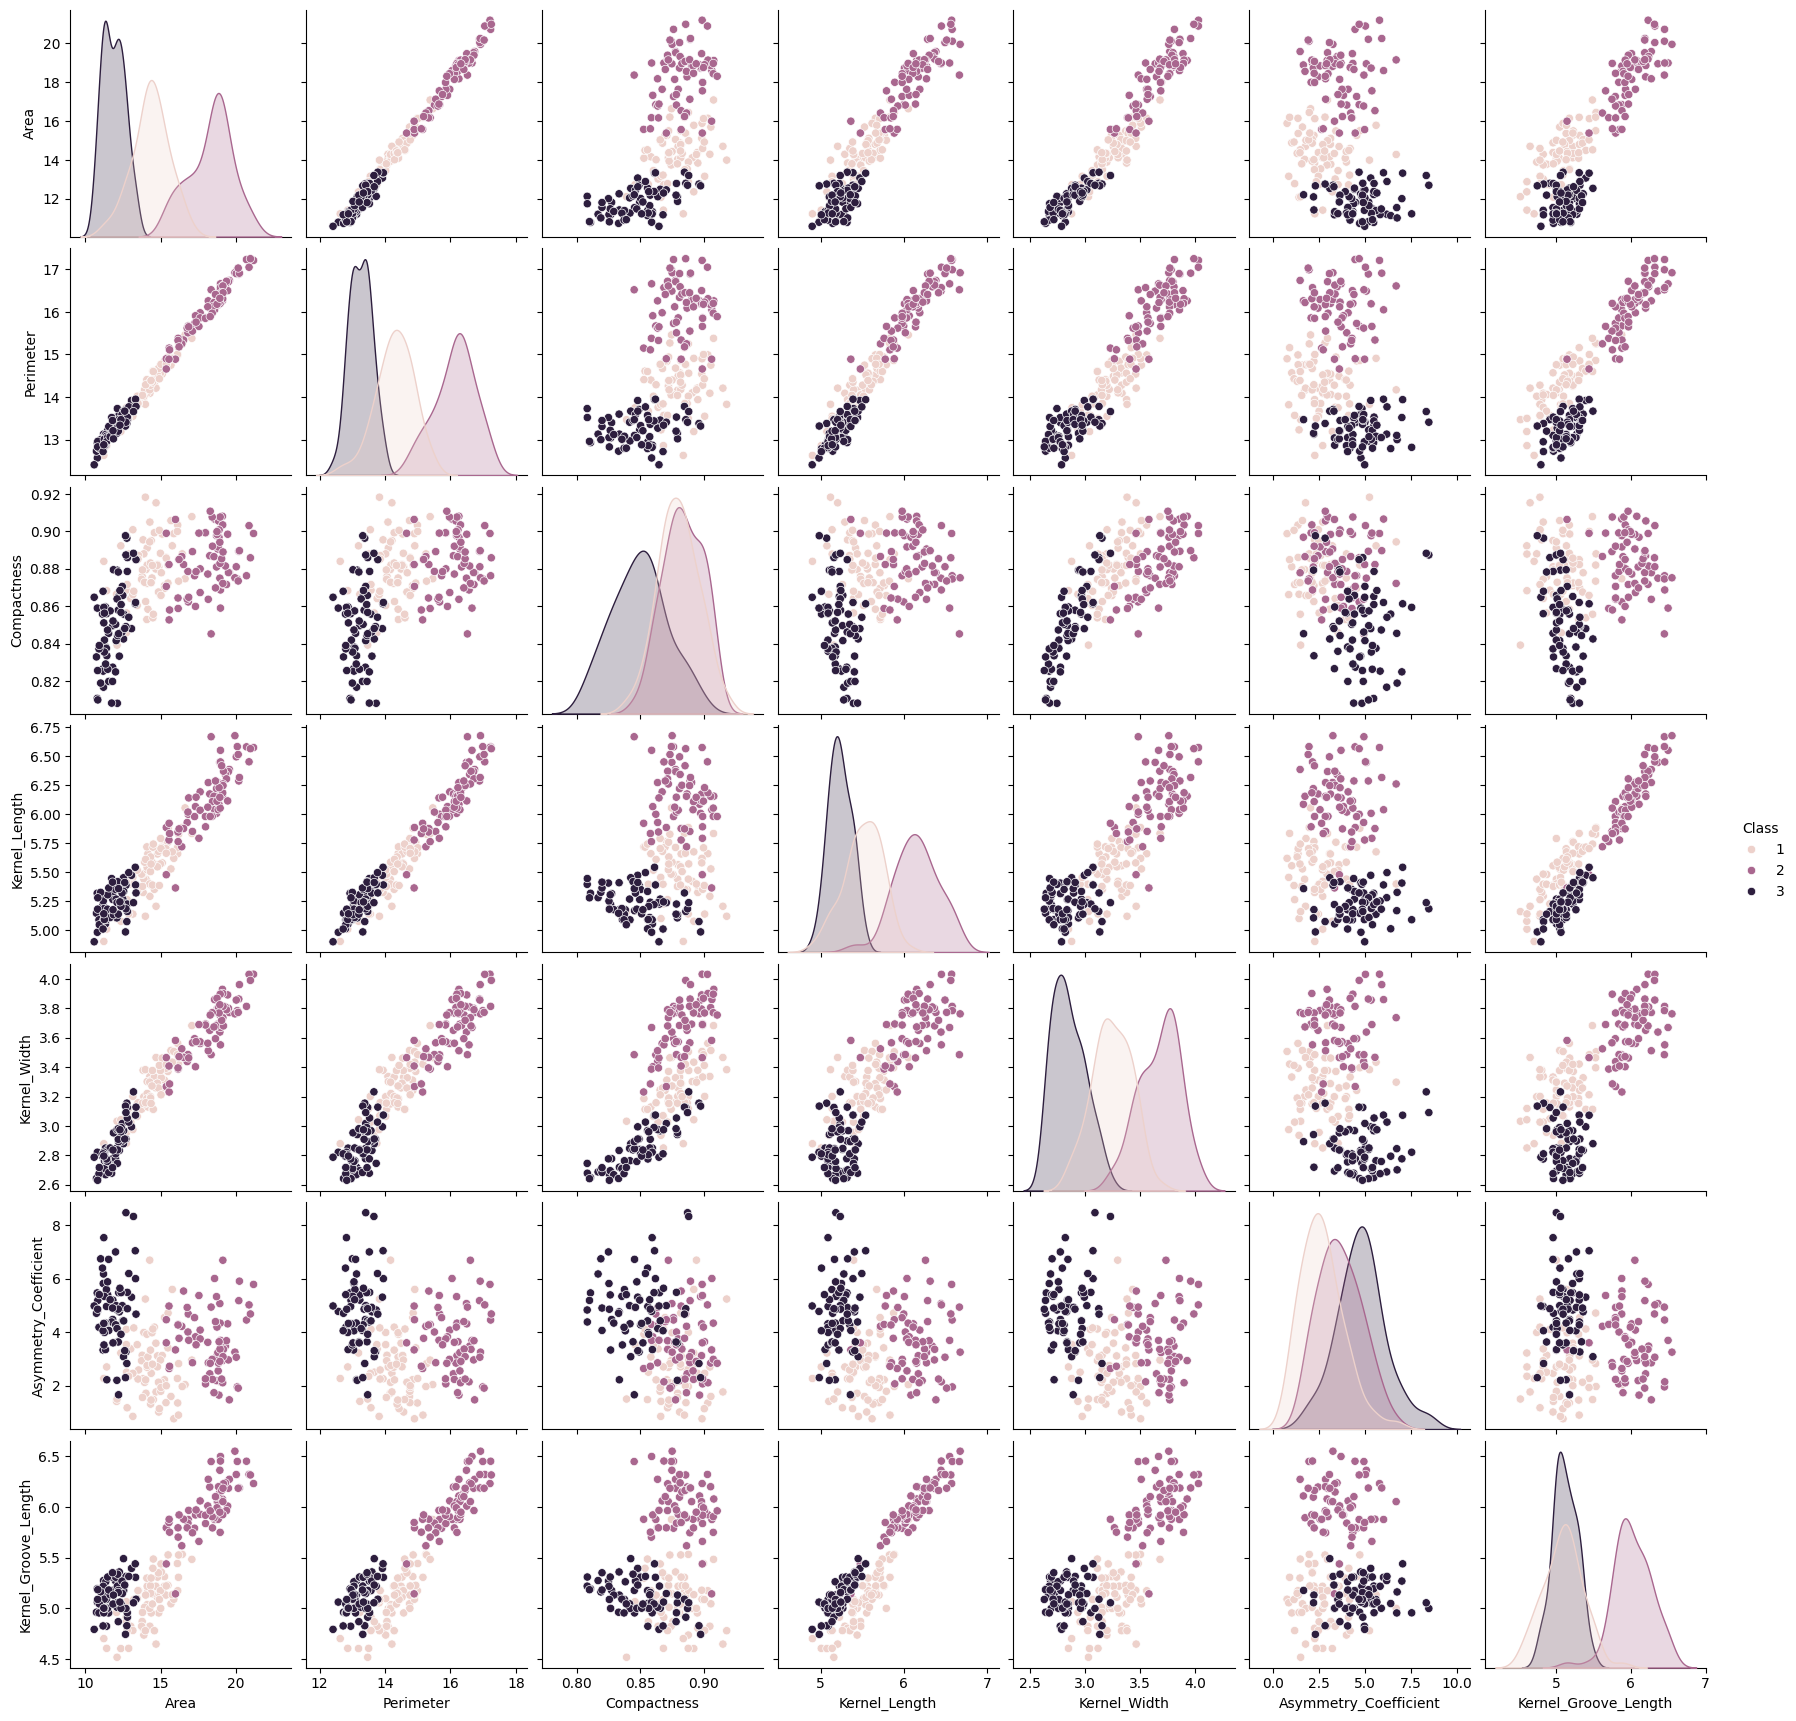

In [ ]:
# Relação entre variáveis

sns.pairplot(
    df,
    hue='Class'
)

plt.show()

In [ ]:
# Verificação de valores ausentes

df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Kernel_Length,0
Kernel_Width,0
Asymmetry_Coefficient,0
Kernel_Groove_Length,0
Class,0


## Tratamento de Valores Ausentes

Não foram identificados valores ausentes no conjunto de dados.
Todas as 210 observações possuem dados completos.

In [ ]:
# Separação entre atributos e classe

X = df.drop('Class', axis=1)

y = df['Class']

In [ ]:
# Padronização

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Padronização concluída.")

Padronização concluída.


In [ ]:
# Divisão dos dados

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (147, 7)
Teste: (63, 7)


In [ ]:
# KNN

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

print("KNN treinado com sucesso!")

KNN treinado com sucesso!


In [ ]:
# SVM

svm = SVC()

svm.fit(X_train, y_train)

print("SVM treinado com sucesso!")

SVM treinado com sucesso!


In [ ]:
# Random Forest

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest treinado com sucesso!")

Random Forest treinado com sucesso!


In [ ]:
# Previsões

y_pred_knn = knn.predict(X_test)

y_pred_svm = svm.predict(X_test)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Função de avaliação

def avaliar_modelo(nome, y_true, y_pred):

    print(f"\n===== {nome} =====")

    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(y_true,
                          y_pred,
                          average='weighted'))

    print("Recall:",
          recall_score(y_true,
                       y_pred,
                       average='weighted'))

    print("F1-Score:",
          f1_score(y_true,
                   y_pred,
                   average='weighted'))

In [ ]:
avaliar_modelo(
    "KNN",
    y_test,
    y_pred_knn
)

avaliar_modelo(
    "SVM",
    y_test,
    y_pred_svm
)

avaliar_modelo(
    "Random Forest",
    y_test,
    y_pred_rf
)


===== KNN =====
Accuracy: 0.873015873015873
Precision: 0.8721441284370346
Recall: 0.873015873015873
F1-Score: 0.8712842712842713

===== SVM =====
Accuracy: 0.873015873015873
Precision: 0.8721441284370346
Recall: 0.873015873015873
F1-Score: 0.8712842712842713

===== Random Forest =====
Accuracy: 0.9206349206349206
Precision: 0.9239417989417988
Recall: 0.9206349206349206
F1-Score: 0.9191697191697191


In [ ]:
print("===== KNN =====")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

print("===== SVM =====")

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

print("===== Random Forest =====")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

===== KNN =====
              precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

===== SVM =====
              precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

===== Random Forest =====
              precision    recall  f1-score   support

           1       0.94      0.81      0.87        21
           2       0.95      0.95      0.95        21
           3     

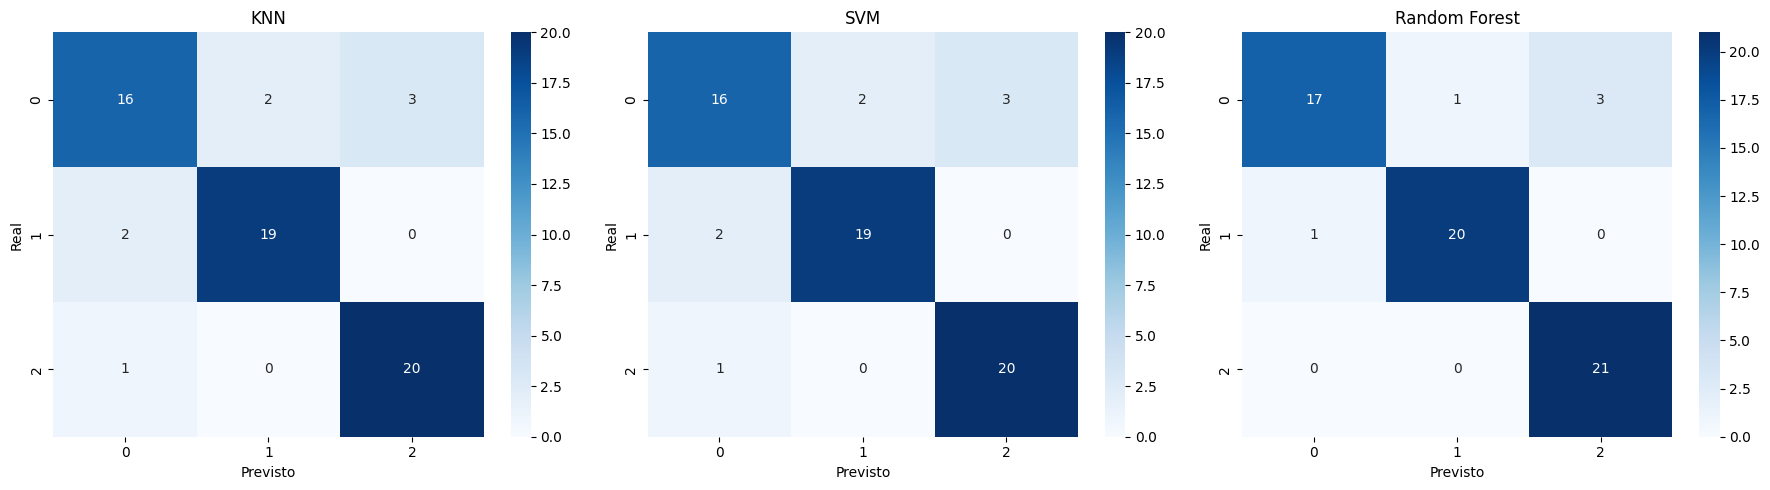

In [ ]:
# Matrizes de confusão

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = {
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

for ax, (nome, pred) in zip(axes, modelos.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )

    ax.set_title(nome)

    ax.set_xlabel("Previsto")

    ax.set_ylabel("Real")

plt.tight_layout()

plt.show()

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

In [ ]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_rf.best_params_)

print("\nMelhor score:")
print(grid_rf.best_score_)

Melhores parâmetros:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Melhor score:
0.9055172413793103


In [24]:
# Modelo otimizado

rf_otimizado = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

rf_otimizado.fit(
    X_train,
    y_train
)

y_pred_rf_ot = rf_otimizado.predict(
    X_test
)

In [25]:
print("Accuracy:",
      accuracy_score(
          y_test,
          y_pred_rf_ot
      ))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf_ot
    )
)

Accuracy: 0.8888888888888888

Classification Report:

              precision    recall  f1-score   support

           1       0.89      0.76      0.82        21
           2       0.95      0.95      0.95        21
           3       0.83      0.95      0.89        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



## Comparação dos Modelos

O modelo KNN apresentou acurácia de 87,30%, demonstrando boa capacidade de classificação dos grãos.

O modelo SVM apresentou desempenho semelhante ao KNN, com acurácia de 87,30%.

O modelo Random Forest apresentou o melhor resultado, alcançando 92,06% de acurácia e 91,92% de F1-Score, demonstrando maior capacidade de generalização e melhor equilíbrio entre precisão e recall.

Após a otimização por meio do GridSearchCV, foram identificados os melhores hiperparâmetros para o Random Forest, permitindo validar a robustez do modelo e confirmar sua adequação para a classificação automática das variedades de trigo.


# Conclusão

A aplicação da metodologia CRISP-DM permitiu desenvolver e avaliar diferentes modelos de Machine Learning para a classificação automática de variedades de trigo utilizando o Seeds Dataset.

Foram realizadas etapas de exploração dos dados, análise estatística, visualização gráfica, padronização dos atributos e treinamento dos modelos KNN, SVM e Random Forest.

Os resultados demonstraram que o Random Forest apresentou o melhor desempenho entre os algoritmos avaliados, atingindo aproximadamente 92% de acurácia no conjunto de teste.

Os resultados indicam que técnicas de Machine Learning podem ser utilizadas com sucesso para automatizar processos de classificação de grãos, reduzindo erros humanos e aumentando a eficiência operacional em cooperativas agrícolas.
